## Dependencies

- The four `PYTHON_JULIACALL_*` variables are read at import, so they are set above it.
- `PYTHON_JULIACALL_EXE` finds your `julia` on PATH; `PYTHON_JULIACALL_PROJECT` is your default Julia environment (`~/.julia/environments/v1.12`), where `] add` installs.
- `"auto"` is one Julia thread per logical CPU; above one thread `HANDLE_SIGNALS="yes"` is mandatory, and juliacall warns Ctrl-C then stops interrupting.
- `juliacall` comes before `numpy` and `matplotlib`: with the system's libcrypto 3.0 resident, Julia's own OpenSSL cannot start.
- Expect that clash here: a Jupyter kernel imports `hashlib` at boot. The one recorded candidate, untested, is an `LD_PRELOAD` in the kernelspec `env` block.

In [1]:
import os, shutil

os.environ["PYTHON_JULIACALL_EXE"] = shutil.which("julia")
os.environ["PYTHON_JULIACALL_PROJECT"] = os.path.expanduser("~/.julia/environments/v1.12")
os.environ["PYTHON_JULIACALL_THREADS"] = "auto"
os.environ["PYTHON_JULIACALL_HANDLE_SIGNALS"] = "yes"

from juliacall import Main as jl

import numpy as np
import matplotlib.pyplot as plt

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## Threads Available

In [2]:
jl.seval("Threads.nthreads()")

24

# System Dynamics

The *true (uncertain) system*:
$$ dX_t = \left[ f(t,X_t) + g(t)U_{\mathcal{L}_1,t} + \Lambda_\mu(t,X_t) \right] dt + \left[p(t,X_t)  \Lambda_\sigma(t,X_t) \right]dW_t, \quad X_0 = x_0 \sim \xi_0. $$
where $X_t \in \mathbb{R}^n$, $U_{\mathcal{L}_1,t} \in \mathbb{R}^{m}$, and  $W_t \in \mathbb{R}^{d}$ is a a standard Brownian motion (SBM).
Additionally, $f(t,X_t) \in \mathbb{R}^n$, $g(t) \in \mathbb{R}^{n \times m}$, and $p(t,X_t) \in \mathbb{R}^{n \times d}$ are **known vector fields,** and $\Lambda_\mu(t,X_t) \in \mathbb{R}^n$ and $\Lambda_\sigma(t,X_t) \in \mathbb{R}^{n \times d}$ are the **drift and diffusion uncertainties**, respectively. 

Dropping the uncertainties, we obtain the *nominal (known) system*:
$$ dX^\star_t = f(t,X^\star_t) dt + p(t,X^\star_t)dW^\star_t, \quad X^\star_0 = x^\star_0 \sim \xi^\star_0, $$
where $\xi^\star_0$ is independent of $\xi^\star_0$ and $W^\star_t$ is an SBM independent of $W_t$

*Remark* Any baseline feedback is absorbed with the known drift $f(t,x)$: Suppose the drift vector field is $f'(t,x)+g(t)U_t$, and we have a baseline law $k(t.\cdot):\mathbb{R}^n \rightarrow \mathbb{R}^m$, then, 
$$f(t,x) \doteq f'(t,x)+g(t)k(t,x), \quad \forall (t,x) \in \mathbb{R}_{\geq 0} \times \mathbb{R}^n$$.

## 1D Double Integrator
The double integrator dynamics is defined by 
$$ 
X_t = \begin{bmatrix} pos(t)  \\ vel(t)  \end{bmatrix}, \quad f(t,x) = (A + BK)x + v(t), \quad g(t) = B,  
$$
where $v(t)$ is a feedfoward signal and $K \in \mathbb{R}^{1 \times 2}$ is a regulator obtained via pole placement, and 
$$ 
A = \begin{bmatrix} 0 & 1 \\ 0 & 0  \end{bmatrix}, \quad  B = \begin{bmatrix} 0  \\ 1  \end{bmatrix}.  
$$
We set $d = 2$, and the remaning vector fields $\Lambda_\mu$, $\Lambda_\sigma$ and, $p$ are set to whatever one wishes to simulate. The initial distributions $\xi_0$ and $\xi_0^star$ are also free to be assigned.

# Setup

## System 

`include` runs the companion file in Julia's `Main`, where `setup_system`, the same function the Julia example defines, stays visible to every later cell.

- Names assigned inside a `jl.seval` string are Julia names in `Main`, which is how the later cells reach `setup`.
- The relative path resolves against the kernel's working directory, the folder holding this notebook.
- Your own dynamics: copy the companion, edit the blocks it marks `EDIT`, and re-run this cell.
- The first run of this cell loads L1DRAC and compiles its dependency tree, 17.7 s once per kernel.

In [3]:
jl.seval('include("CompanionPyFront_doubleintegrator1D.jl")')

Ntraj = 1_000 # Trajectories per ensemble
setup = jl.seval(f"setup = setup_system(; Ntraj={Ntraj})")

# Solving

- Select which systems to simulate by setting `systems` to be any non-empty subset $\in$ {`:nominal_sys`, `:true_sys`, `:L1_sys`}; the string is spliced into the call as Julia source.
- `max_GPUs=0` runs on the CPU threads and `max_GPUs=1` on one GPU, the fast default for this workload; a larger number is capped at the GPUs present.
- The warm-up run buys the compilation: 17.5 s for the first CPU run against 3.1 s warm, and 38.3 s for the first GPU call.

In [4]:
max_GPUs = 1
systems = "[:nominal_sys, :true_sys, :L1_sys]"

_ = jl.seval("warmup_setup = setup_system(; Ntraj=10)")
_ = jl.seval(f"run_simulations(warmup_setup; max_GPUs={max_GPUs}, systems={systems})")

 24.357352 seconds (48.26 M CPU allocations: 2.311 GiB, 2.21% gc time) (4 GPU allocations: 61.762 KiB, 0.07% memmgmt time)


┌ Info: GPU mode
│   max_GPUs = 1
└   available_GPUs = 3
[ Info: Running Ensemble Simulation of Nominal System (GPU)
[ Info: Done
[ Info: Running Ensemble Simulation of True System (GPU)
IOStream.flush timed out
[ Info: Done
[ Info: Running Ensemble Simulation of L1-DRAC System (GPU)
[ Info: Done
[ Info: CPU and GPU memory reclaimed


  2.398663 seconds (6.45 M CPU allocations: 321.915 MiB, 1.41% gc time) (4 GPU allocations: 61.762 KiB, 0.00% memmgmt time)
  5.215854 seconds (12.74 M CPU allocations: 632.390 MiB, 1.36% gc time) (4 GPU allocations: 160.395 KiB, 0.00% memmgmt time)


In [5]:
solutions = jl.seval(f"solutions = run_simulations(setup; max_GPUs={max_GPUs}, systems={systems})")

  0.123164 seconds (41.21 k CPU allocations: 8.307 MiB) (4 GPU allocations: 5.842 MiB, 0.28% memmgmt time)
  0.305892 seconds (41.36 k CPU allocations: 8.311 MiB) (4 GPU allocations: 5.842 MiB, 0.01% memmgmt time)
  0.382858 seconds (42.27 k CPU allocations: 18.597 MiB) (4 GPU allocations: 15.474 MiB, 0.01% memmgmt time)


┌ Info: GPU mode
│   max_GPUs = 1
└   available_GPUs = 3
[ Info: Running Ensemble Simulation of Nominal System (GPU)
[ Info: Done
[ Info: Running Ensemble Simulation of True System (GPU)
[ Info: Done
[ Info: Running Ensemble Simulation of L1-DRAC System (GPU)
[ Info: Done
[ Info: CPU and GPU memory reclaimed


# DATA LOGGING

## Saving data

- Select which systems to save data for by adding `systems=[...]`, any non-empty subset $\in$ {`:nominal_sys`, `:true_sys`, `:L1_sys`}, to the call.
- If the `systems` option is not used, all the simulated systems have their data saved.
- A relative `path` resolves against the kernel's working directory, so `"sol_logs"` is a folder beside this notebook.
- Each file holds the time grid and every trajectory as solved; no statistics are stored.

In [6]:
jl.seval('state_logging(solutions; path="sol_logs")') # One .jld2 file per system

(nominal = "sol_logs/states_nominal.jld2", true_sys = "sol_logs/states_true.jld2", L1 = "sol_logs/states_L1.jld2")

## Loading data

- Each file rebuilds into a full ensemble, linear interpolant included, so off-grid times work.
- Slicing at load leaves L1 with the same two state components as nominal and true.
- Beyond $X$, the saved L1 state carries a predictor, a filter, and an adaptive estimate, loaded with `:L1_predictor`, `:L1_filter`, `:L1_adaptive_estimate`:
    - E.g. `jl.seval('L1_adaptive_estimate_sol = load_ensemble(joinpath(log_path, "states_L1.jld2"); component=:L1_adaptive_estimate, system_dimensions=setup.system_dimensions)')`
- A later session needs no re-simulation: `system_dimensions` comes from `setup_system()` alone.

In [7]:
jl.seval('log_path = "sol_logs"')

jl.seval('nominal_sol = load_ensemble(joinpath(log_path, "states_nominal.jld2"))')
jl.seval('true_sol    = load_ensemble(joinpath(log_path, "states_true.jld2"))')
jl.seval('L1_sol      = load_ensemble(joinpath(log_path, "states_L1.jld2"); component=:L1_sys_states, system_dimensions=setup.system_dimensions)') # The L1 file holds the full extended state; keep only X

_ = jl.seval("loaded_solutions = (; nominal_sol, true_sol, L1_sol)")

# Plotting

## Ensemble statistics( )

Per-timepoint statistics over all trajectories of one ensemble: for each state component $X_i$, the empirical $k$-th moment $\left( \mathbb{E}\left[ |X_i|^k \right] \right)^{1/k}$, the median, and the $[\delta, 1-\delta]$ quantiles.

Each ensemble crosses into numpy once, as an array of components $\times$ time $\times$ trajectories: `stack` collapses it on the Julia side and `np.asarray` wraps that memory without copying it.

In [8]:
def ensemble_stats(esol, k=2, δ=0.05, components=slice(None)): # esol names an ensemble on the Julia side, e.g. "loaded_solutions.nominal_sol"
    t = np.asarray(jl.seval(f"collect(Float64, {esol}.u[1].t)"))
    X = np.asarray(jl.seval(f"stack(stack(traj.u) for traj in {esol}.u)"))[components] # np.array(X) instead, to own a copy
    moment = np.mean(np.abs(X) ** k, axis=2) ** (1 / k)
    med = np.median(X, axis=2)
    qlow, qhigh = np.quantile(X, [δ, 1 - δ], axis=2)
    return {"t": t, "X": X, "moment": moment, "med": med, "qlow": qlow, "qhigh": qhigh}

## States vs time( )

A $3 \times 2$ figure: the columns are the state components $X_1$ and $X_2$, and the rows are the sample paths, the $k$-th moments, and the median with the $[\delta, 1-\delta]$ band. The nominal, true, and $\mathcal{L}_1$ systems are overlaid in every panel.

In [9]:
def plot_states_vs_time(sol, k=2, δ=0.05, max_traj_plot=500): # sol names the ensembles' NamedTuple on the Julia side
    systems = (("nominal_sol", "tab:purple", "nominal"),
               ("true_sol", "tab:orange", "true"),
               ("L1_sol", "tab:blue", "L1-DRAC"))

    fig, axes = plt.subplots(3, 2, figsize=(9, 11), sharex=True)

    for field, color, label in systems:
        st = ensemble_stats(f"{sol}.{field}", k=k, δ=δ, components=slice(0, 2)) # Rows 0-1 are X, including in L1's extended state
        t, X = st["t"], st["X"]
        paths = min(max_traj_plot, X.shape[2]) # Row 1 draws only the first min(max_traj_plot, Ntraj) paths

        for i in (0, 1):
            axes[0, i].plot(t, X[i, :, :paths], color=color, lw=0.5, alpha=0.3)
            axes[1, i].plot(t, st["moment"][i], color=color, lw=1.5)
            axes[2, i].plot(t, st["med"][i], color=color, lw=1.5)
            axes[2, i].fill_between(t, st["qlow"][i], st["qhigh"][i], color=color, alpha=0.2)

        axes[0, 0].plot([], [], color=color, label=label) # Empty line, drawn for the legend alone

    axes[0, 0].set_title("X1")
    axes[0, 1].set_title("X2")
    axes[1, 0].set_ylabel(f"Moment: {k}")
    axes[2, 0].set_ylabel(f"Quantiles: [{δ}, {1 - δ}]")
    axes[2, 0].set_xlabel("t")
    axes[2, 1].set_xlabel("t")
    axes[0, 0].legend(loc="upper right", fontsize=8)
    fig.tight_layout()
    return fig

## Plots Generation

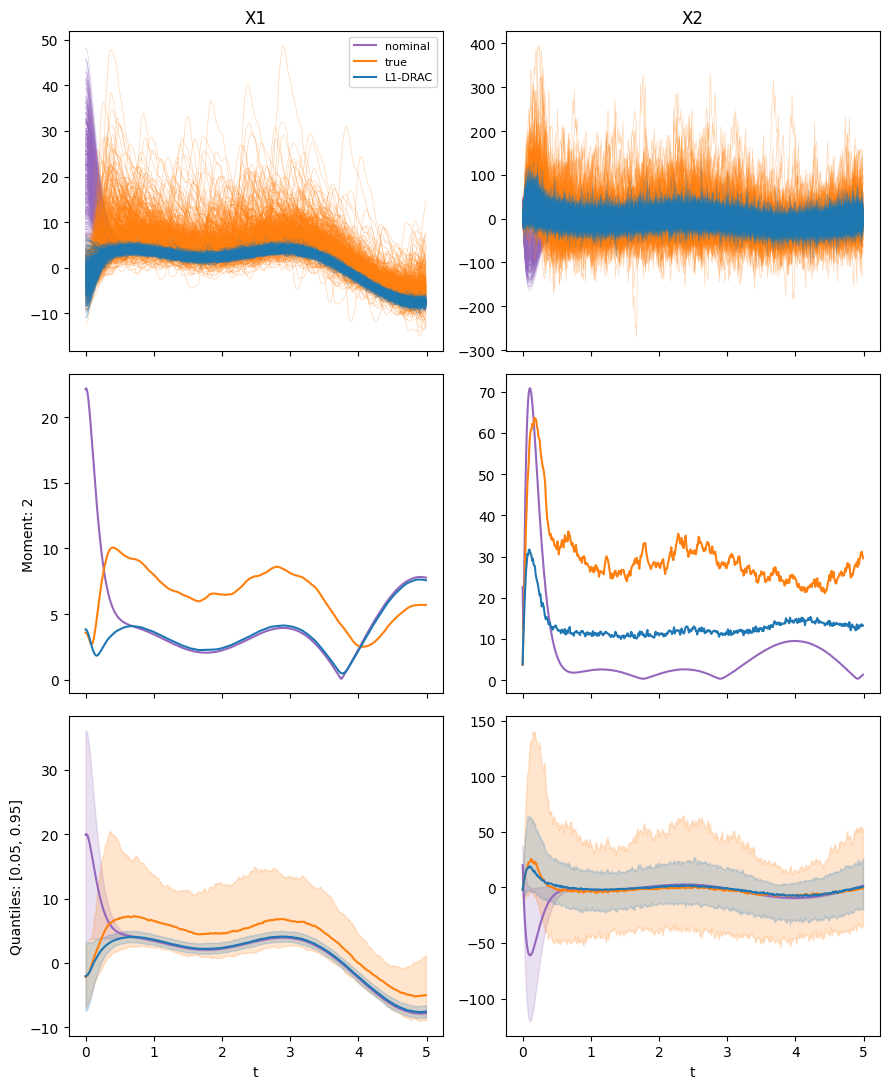

In [10]:
fig = plot_states_vs_time("loaded_solutions") # Also accepts "solutions", the live run